In [2]:
from netCDF4 import Dataset
import wrf

# --- Define your desired 3D box ---
# Lower-left corner
lat_ll = -41.5
lon_ll = -67.0
# Upper-right corner
lat_ur = -37.5
lon_ur = -62.0
# ----------------------------------

# Open one of your WRF files
base_path1 = "/home/jorge.gacitua/datosmunin2/EXPERIMENTS_UNWEATHER/DATA/PREVENIR_LOWRESOLUTION_HYDRA_2023121612/HIST/FCST/20231216120000/001/wrfout_d01_2023-12-16_19:00:00"
ncfile = Dataset(base_path1)

# Compute xy indices
# Note: returns (x, y) which corresponds to (i, j)
xy_ll = wrf.ll_to_xy(ncfile, lat_ll, lon_ll)
xy_ur = wrf.ll_to_xy(ncfile, lat_ur, lon_ur)
lat_ll_wrf, lon_ll_wrf = wrf.xy_to_ll(ncfile, xy_ll[0], xy_ll[1])
lat_ur_wrf, lon_ur_wrf = wrf.xy_to_ll(ncfile, xy_ur[0], xy_ur[1])

i_start = int(xy_ll.values[0])
i_end = int(xy_ur.values[0]) + 1 # +1 for Python slicing
j_start = int(xy_ll.values[1])
j_end = int(xy_ur.values[1]) + 1 # +1 for Python slicing

print(f"Found indices:")
print(f"  i_start: {i_start}  (west_east)")
print(f"  i_end:   {i_end}")
print(f"  j_start: {j_start}  (south_north)")
print(f"  j_end:   {j_end}")

print("\nAdd this to your YAML config:")
print("subset_3d:")
print(f"  i_start: {i_start}")
print(f"  i_end: {i_end}")
print(f"  j_start: {j_start}")
print(f"  j_end: {j_end}")

print(f"lat_ll: {lat_ll}, lon_ll: {lon_ll}")
print(f"lat_ur: {lat_ur}, lon_ur: {lon_ur}")
print(f"lat_ll_wrf: {lat_ll_wrf.values}, lon_ll_wrf: {lon_ll_wrf.values}")
print(f"lat_ur_wrf: {lat_ur_wrf.values}, lon_ur_wrf: {lon_ur_wrf.values}")  

Found indices:
  i_start: 174  (west_east)
  i_end:   280
  j_start: 223  (south_north)
  j_end:   339

Add this to your YAML config:
subset_3d:
  i_start: 174
  i_end: 280
  j_start: 223
  j_end: 339
lat_ll: -41.5, lon_ll: -67.0
lat_ur: -37.5, lon_ur: -62.0
lat_ll_wrf: -41.51332124387697, lon_ll_wrf: -66.99607480645261
lat_ur_wrf: -37.49035104942939, lon_ur_wrf: -61.999994208812154


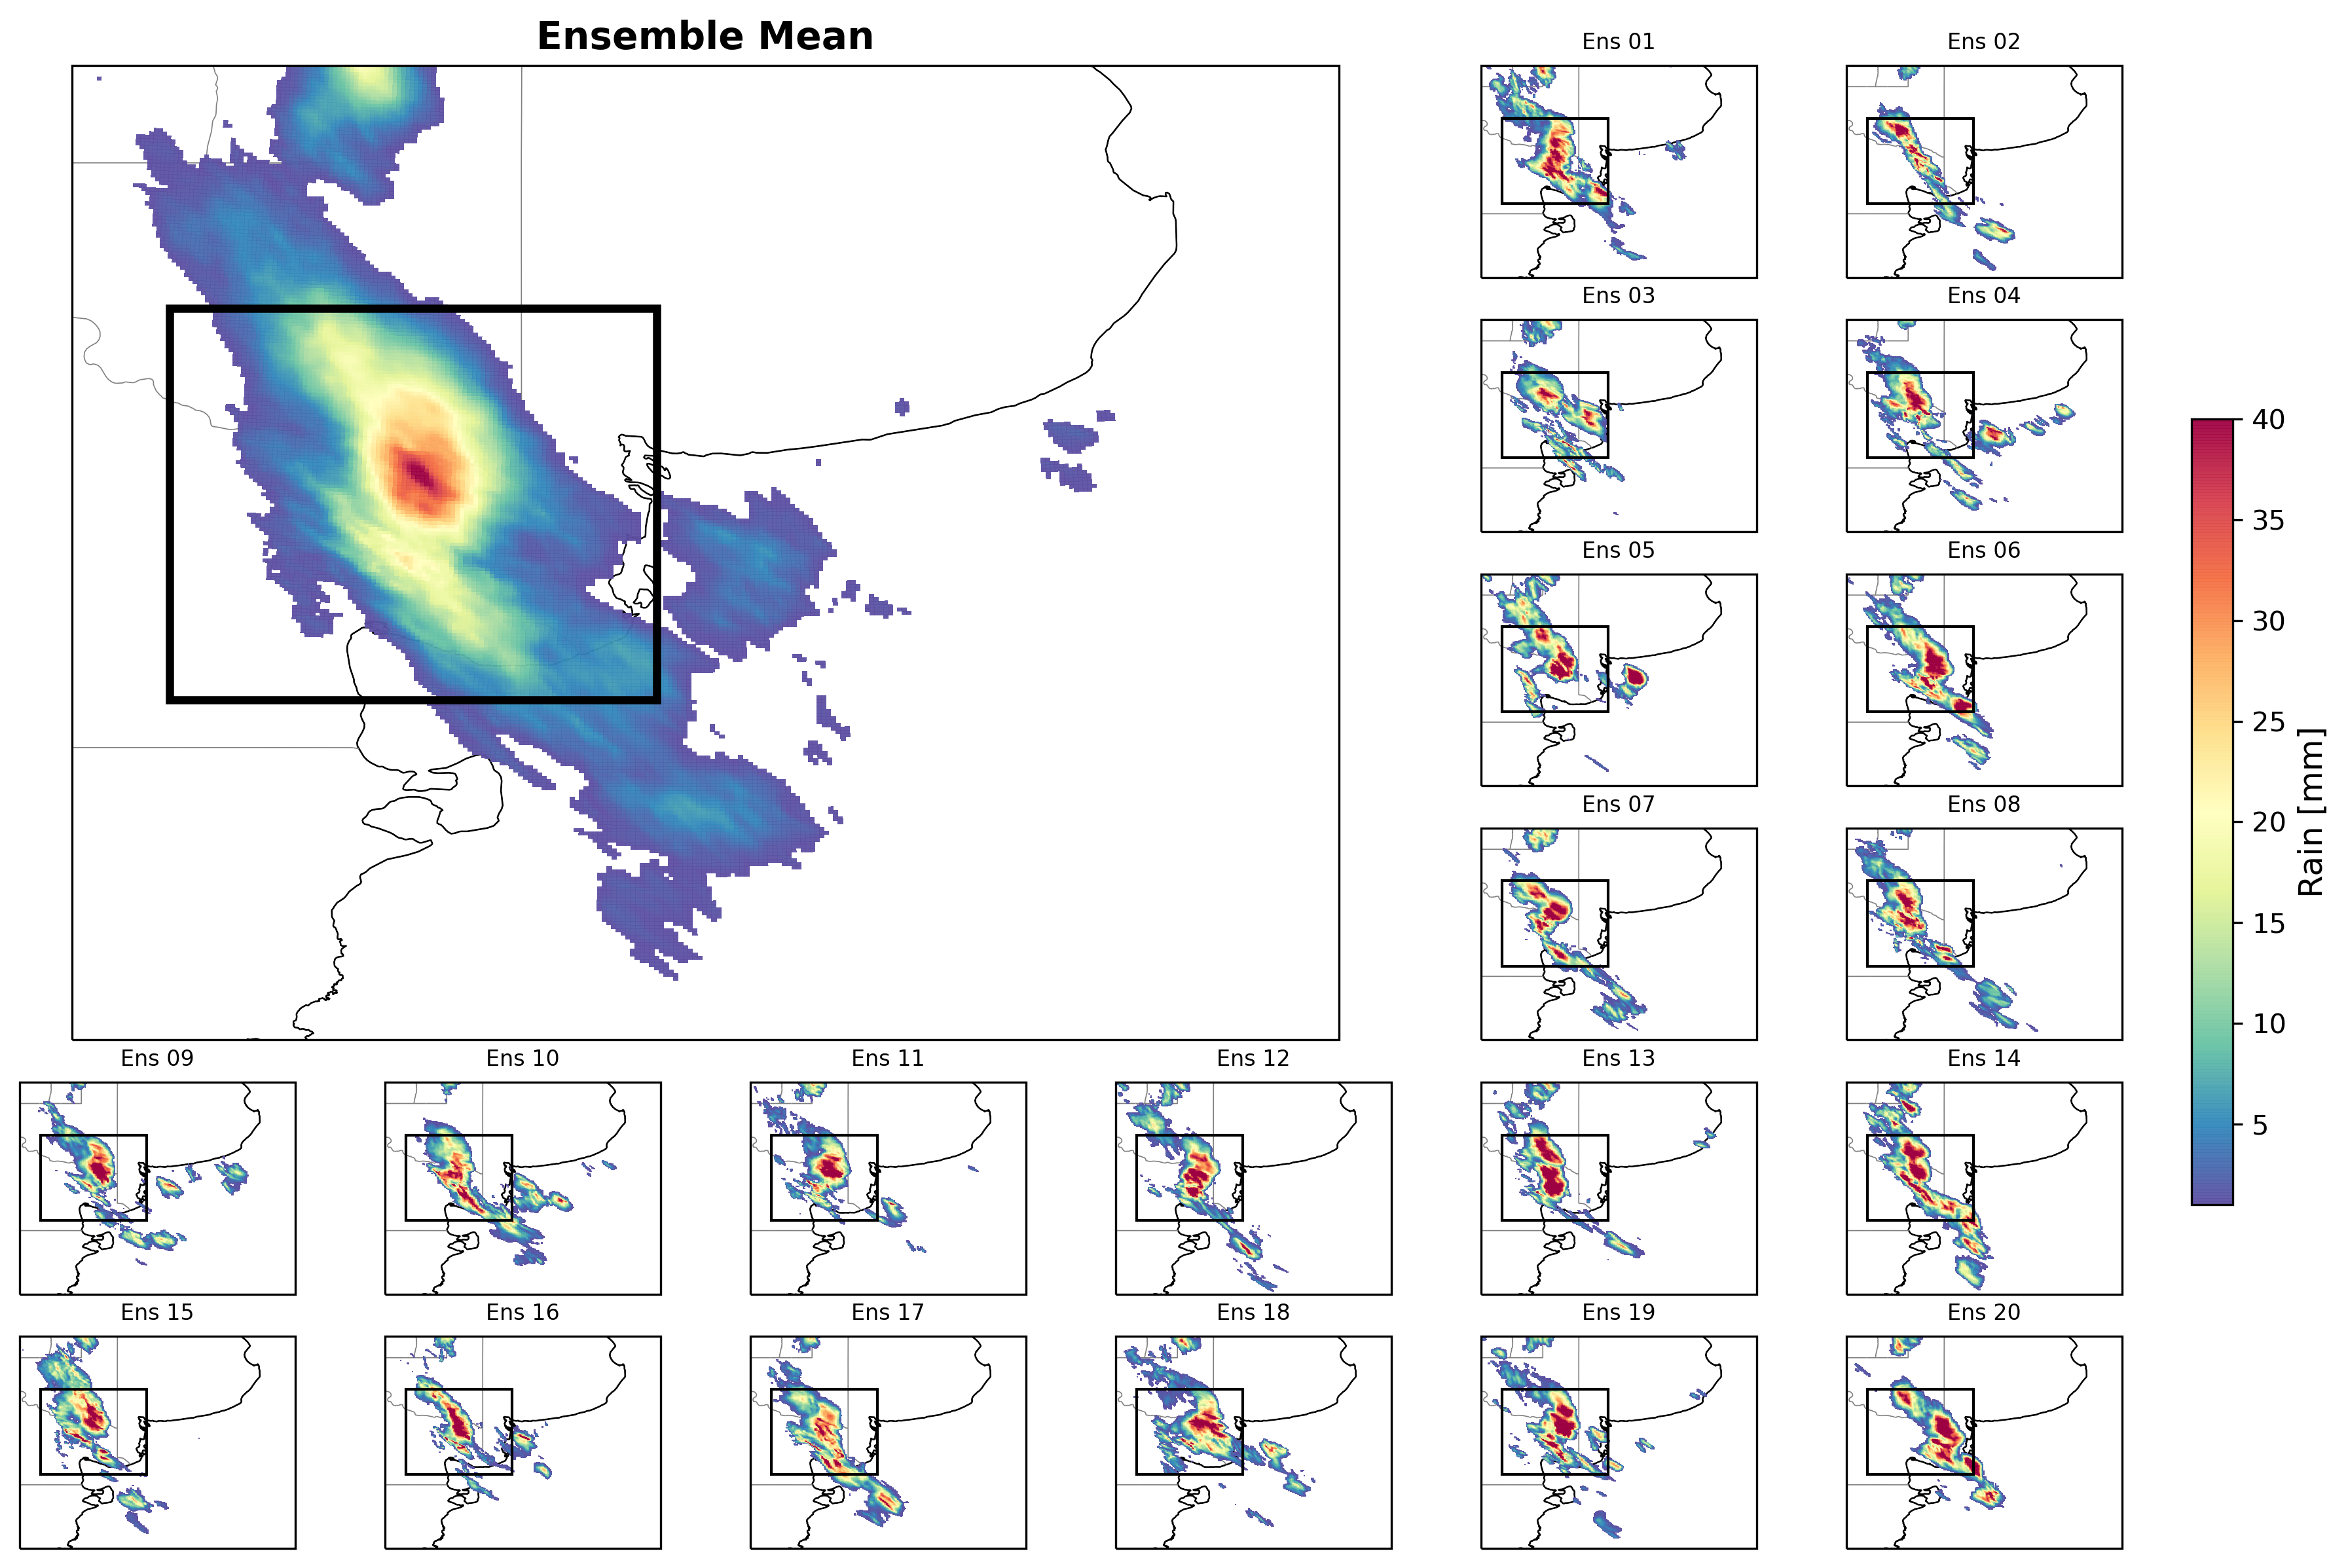

In [3]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from netCDF4 import Dataset
from wrf import getvar
#ignore warnings
import warnings
warnings.filterwarnings("ignore")

# Define map features
states_provinces = cfeature.NaturalEarthFeature(
    category='cultural',
    name='admin_1_states_provinces_lines',
    scale='10m',
    facecolor='none', edgecolor='gray')

countries = cfeature.NaturalEarthFeature(
    category='cultural',
    name='admin_0_countries',
    scale='10m',
    facecolor='none', edgecolor='black')

def plot_axis_map(ax, lons, lats, data, vmin=1, vmax=200, cmap='Spectral_r', proj=ccrs.PlateCarree()):
    """ Plots a map with the given data on the specified axis. """
    lonwest, loneast = -68, -55
    latsouth, latnorth = -45, -35
    ax.set_extent([lonwest, loneast, latsouth, latnorth], crs=proj)

    cm = ax.pcolormesh(lons, lats, data, cmap=cmap, vmin=vmin, vmax=vmax, 
                        linewidths=0.5, edgecolors='none', zorder=2, alpha=0.95, transform=proj)

    ax.coastlines(resolution='10m', linewidth=0.6)
    ax.add_feature(countries, linewidth=0.4)
    ax.add_feature(states_provinces, linewidth=0.4)

    # Remove axis labels and ticks
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xticklabels([])
    ax.set_yticklabels([])

    return cm
def plot_ensemble_members(base_path1, base_path2, vlim_min):
    """
    Plots rain difference for all ensemble members (001 to 030).
    """
    nens = 30  # Number of ensemble members

    ensemble_data = []

    for ensmem in range(nens):
        mem_str = f"{ensmem+1:03}"
        file1 = f"{base_path1}/{mem_str}/wrfout_d01_2023-12-16_18:00:00"
        file2 = f"{base_path2}/{mem_str}/wrfout_d01_2023-12-16_19:00:00"

        # Read WRF files
        wrfin1 = Dataset(file1)
        wrfin2 = Dataset(file2)

        lat = getvar(wrfin1, 'lat')
        lon = getvar(wrfin1, 'lon')
        data1 = getvar(wrfin1, 'RAINNC')
        data2 = getvar(wrfin2, 'RAINNC')

        time = getvar(wrfin2, 'times').to_numpy()
        date_str = np.datetime_as_string(time)[0:19]

        # Compute rain difference
        data = np.ma.masked_less(data2 - data1, vlim_min)
        ensemble_data.append(data)


    return ensemble_data, lon, lat, date_str

def plot_highlighted_ensemble_top_left(ensemble_data, lon, lat, date_str, highlight_idx=0, vlim_min=1, vlim_max=40, cmap='Spectral_r'):
    """
    Plots a selected ensemble member in the top-left (2x2 grid), with other members filling the rest of a 4x4 grid.
    """
    nens = len(ensemble_data)
    n_display = min(nens - 1, 20)  # Limit surrounding members to 12

    # Create figure with GridSpec (4x4 layout)
    fig = plt.figure(figsize=(14, 10), dpi=300)
    gs = fig.add_gridspec(6, 6, width_ratios=[1, 1, 1, 1,1,1], height_ratios=[1, 1, 1, 1,1,1]) 

    # Large top-left subplot for highlighted member (2x2)
    ax_main = fig.add_subplot(gs[0:4, 0:4], projection=ccrs.PlateCarree())
    if highlight_idx == -1:
        data_to_plot = np.ma.masked_less(np.mean(ensemble_data, axis=0), vlim_min)
        title_main = "Ensemble Mean"
    else:
        data_to_plot = np.ma.masked_less(ensemble_data[highlight_idx], vlim_min)
        title_main = f"Ens {highlight_idx+1:02}"
    
    cm = plot_axis_map(ax_main, lon, lat, data_to_plot, vmin=vlim_min, vmax=vlim_max, cmap=cmap)
    dif_lat = lat_ur_wrf - lat_ll_wrf
    dif_lon = lon_ur_wrf - lon_ll_wrf
    square = patches.Rectangle((lon_ll_wrf, lat_ll_wrf), dif_lon, dif_lat, facecolor='None', edgecolor='black', linewidth=3, transform=ccrs.PlateCarree(), zorder=5, alpha=1)
    ax_main.add_patch(square)
    
    ax_main.set_title(title_main, fontsize=14, fontweight="bold")

    # Select surrounding members (skip highlighted)
    surrounding_idx = [i for i in range(nens) if i != highlight_idx][:n_display]
    
    # Remaining positions for the 12 members
    remaining_positions = [(i // 6, i % 6) for i in range(36) if i not in [0, 1, 2, 3, 6, 7, 8, 9, 12, 13, 14, 15,18, 19, 20,21]]  # Skip (0,0) to (1,1)

    # Surrounding subplots
    ax_list = []
    for i, ens_idx in enumerate(surrounding_idx):
        row, col = remaining_positions[i]
        ax = fig.add_subplot(gs[row, col], projection=ccrs.PlateCarree())
        plot_axis_map(ax, lon, lat, ensemble_data[ens_idx], vmin=vlim_min, vmax=vlim_max, cmap=cmap)
        square = patches.Rectangle((lon_ll_wrf, lat_ll_wrf), dif_lon, dif_lat, facecolor='None', edgecolor='black', linewidth=1, transform=ccrs.PlateCarree(), zorder=5, alpha=1)
        ax.add_patch(square)
        ax.set_title(f"Ens {ens_idx+1:02}", fontsize=8)
        ax_list.append(ax)

    # Add colorbar
    cbar_ax = fig.add_axes([0.92, 0.3, 0.015, 0.4])  
    cbar = fig.colorbar(cm, cax=cbar_ax)
    cbar.ax.tick_params(labelsize=10)
    cbar.set_label('Rain [mm]', fontsize=12)

    #fig.suptitle(f"WRF 2km Ensemble Highlight\n{date_str}", fontsize=16)
    #plt.tight_layout(rect=[0, 0, 0.9, 1])
    plt.show()

if __name__ == "__main__":
    base_path1 = "/home/jorge.gacitua/datosmunin2/EXPERIMENTS_UNWEATHER/DATA/PREVENIR_LOWRESOLUTION_HYDRA_2023121612/HIST/FCST/20231216120000"
    base_path2 = "/home/jorge.gacitua/datosmunin2/EXPERIMENTS_UNWEATHER/DATA/PREVENIR_LOWRESOLUTION_HYDRA_2023121612/HIST/FCST/20231216120000"

    # Load ensemble members
    ensemble_data, lon, lat, date_str = plot_ensemble_members(base_path1, base_path2, vlim_min=1)

    # Plot one highlighted member in the top-left (2x2 space) with others filling the grid
    plot_highlighted_ensemble_top_left(ensemble_data, lon, lat, date_str, highlight_idx=-1, vlim_min=1, vlim_max=40, cmap='Spectral_r')


In [82]:
# 1. --- IMPORTS ---
import os
import argparse
import yaml
import numpy as np
# Use the notebook-friendly version of tqdm
from tqdm.notebook import tqdm 
import pandas as pd
from netCDF4 import Dataset
import wrf

# 2. --- HELPER FUNCTIONS ---
# (These are from your original script)

def _expand_members(mem_ini: int, mem_end: int, pad: int):
    return [str(i).zfill(pad) for i in range(mem_ini, mem_end + 1)]

def _resolve_paths(cfg,date):
    p = cfg["cross_sections_job"]["paths"]
    ens = cfg["cross_sections_job"]["ensemble"]
    pattern = p.get("pattern") or p.get("template")
    if pattern is None:
        raise ValueError("Provide cross_sections_job.paths.pattern (recommended) or .template")

    members = _expand_members(ens["mem_ini"], ens["mem_end"], ens.get("pad", 0))
    if "{member}" in pattern:
        nc_paths = [pattern.format(member=m,date=date) for m in members]
    else:
        nc_paths = [pattern for _ in members]
    out_path = p["output"].format(date=date)
    return members, nc_paths, out_path

def _get_vars(nc, timeidx):
    """
    Returns dict with required WRF variables as xarray.DataArray:
      QGRAUP, QRAIN, QSNOW, tk (K), pressure (Pa), ua, va, wa, and z (m).
    """
    qg = wrf.getvar(nc, "QGRAUP", timeidx=timeidx, meta=True)
    qr = wrf.getvar(nc, "QRAIN",  timeidx=timeidx, meta=True)
    qs = wrf.getvar(nc, "QSNOW",  timeidx=timeidx, meta=True)
    tk = wrf.getvar(nc, "temp",   timeidx=timeidx, meta=True)
    p  = wrf.getvar(nc, "pres",   timeidx=timeidx, meta=True)
    ua = wrf.getvar(nc, "ua",     timeidx=timeidx, meta=True)  # m/s
    va = wrf.getvar(nc, "va",     timeidx=timeidx, meta=True)  # m/s
    wa = wrf.getvar(nc, "wa",     timeidx=timeidx, meta=True)  # m/s
    z  = wrf.getvar(nc, "z",      timeidx=timeidx, meta=True)    # m
    return dict(QGRAUP=qg, QRAIN=qr, QSNOW=qs, tk=tk, pressure=p, ua=ua, va=va, wa=wa, z=z)

# 3. --- MAIN PROCESSING FUNCTION ---
# (This is the 'main' function adapted to take a config_path)

def process_data(config_path):
    with open(config_path, "r") as f:
        cfg = yaml.safe_load(f)

    date_ini = cfg["cross_sections_job"]["paths"].get("init_date")
    date_end = cfg["cross_sections_job"]["paths"].get("end_date")
    freq     = cfg["cross_sections_job"]["paths"].get("freq", "1H")
    
    if date_ini is None or date_end is None:
        print("[error] date_ini and date_end must be specified in the YAML.")
        return

    dates = pd.date_range(start=pd.to_datetime(date_ini,format="%Y-%m-%d_%H:%M:%S"), 
                          end=pd.to_datetime(date_end,format="%Y-%m-%d_%H:%M:%S"), freq=freq)
    print(f"[info] generating 3D subsets for {len(dates)} dates from {date_ini} to {date_end} every {freq}")
    
    for date in dates:
        date = date.strftime("%Y-%m-%d_%H:%M:%S")
        print(f"--- Processing date: {date} ---")

        job = cfg["cross_sections_job"]
        members, nc_paths, out_path = _resolve_paths(cfg, date)

        sub_cfg = job["subset_3d"]
        timeidx = sub_cfg.get("timeidx", -1)
        
        k_slice = slice(sub_cfg.get("k_start"), sub_cfg.get("k_end"))
        j_slice = slice(sub_cfg.get("j_start"), sub_cfg.get("j_end"))
        i_slice = slice(sub_cfg.get("i_start"), sub_cfg.get("i_end"))
        
        os.makedirs(os.path.dirname(out_path), exist_ok=True)

        print(f"[info] probing shapes from {nc_paths[0]}")
        with Dataset(nc_paths[0]) as nc0:
            v0 = _get_vars(nc0, timeidx)
            lat = wrf.getvar(nc0, "lat", timeidx=timeidx, meta=True)
            lon = wrf.getvar(nc0, "lon", timeidx=timeidx, meta=True)

            samp = v0["tk"][k_slice, j_slice, i_slice]
            nz, ny, nx = samp.shape
            
            lats_sub = wrf.to_np(lat[j_slice, i_slice])
            lons_sub = wrf.to_np(lon[j_slice, i_slice])
            z_heights_sub = wrf.to_np(v0["z"][k_slice, j_slice, i_slice])

        nvar = 8
        Ne   = len(nc_paths)
        
        out = np.zeros((nx, ny, nz, Ne, nvar))

        print(f"[info] 3D subset dims: nx={nx}, ny={ny}, nz={nz}, Ne={Ne}, nvar={nvar}")
        print("[info] variable order: [QGRAUP, QRAIN, QSNOW, T, P, UA, VA, WA]")

        for j, path in enumerate(tqdm(nc_paths, desc="members")):
            if not os.path.isfile(path):
                print(f"[warning] Missing WRF file for member {members[j]}: {path}. Skipping.")
                out[:, :, :, j, :] = np.nan
                continue
                
            with Dataset(path) as nc:
                v = _get_vars(nc, timeidx)

                sub_qg = wrf.to_np(v["QGRAUP"][k_slice, j_slice, i_slice])
                sub_qr = wrf.to_np(v["QRAIN"][k_slice, j_slice, i_slice])
                sub_qs = wrf.to_np(v["QSNOW"][k_slice, j_slice, i_slice])
                sub_tk = wrf.to_np(v["tk"][k_slice, j_slice, i_slice])
                sub_p  = wrf.to_np(v["pressure"][k_slice, j_slice, i_slice])
                sub_ua = wrf.to_np(v["ua"][k_slice, j_slice, i_slice])
                sub_va = wrf.to_np(v["va"][k_slice, j_slice, i_slice])
                sub_wa = wrf.to_np(v["wa"][k_slice, j_slice, i_slice])

                out[:, :, :, j, 0] = sub_qg.T
                out[:, :, :, j, 1] = sub_qr.T
                out[:, :, :, j, 2] = sub_qs.T
                out[:, :, :, j, 3] = sub_tk.T
                out[:, :, :, j, 4] = sub_p.T
                out[:, :, :, j, 5] = sub_ua.T
                out[:, :, :, j, 6] = sub_va.T
                out[:, :, :, j, 7] = sub_wa.T
        
        out = out.astype(np.float32, copy=False)

        finite_z = np.isfinite(out).any(axis=(0, 1, 3, 4))
        dropped = int((~finite_z).sum())
        
        if dropped:
            nz0 = out.shape[2]
            print(f"[clean] WARNING: Dropped {dropped} all-NaN z-level(s).")
            print(f"        Consider adjusting k_start in your config.")
            out = out[:, :, finite_z, :, :]
            z_heights_sub = z_heights_sub[finite_z, :, :]
            
        np.savez_compressed(
            out_path, 
            state_ensemble=out,
            lats=lats_sub,
            lons=lons_sub,
            z_heights=z_heights_sub
        )
        print(f"[done] wrote: {out_path} (shape: {out.shape})")
    
    print("\n[info] All dates processed successfully.")


# 4. --- CONFIGURATION AND EXECUTION ---


CONFIG_FILE = "/home/jorge.gacitua/datosmunin/wrf_python_Assimilation/configs/build_3D_section.yaml" 

# Run the processing
process_data(CONFIG_FILE)

[info] generating 3D subsets for 1 dates from 2023-12-16_19:00:00 to 2023-12-16_19:00:00 every 1h
--- Processing date: 2023-12-16_19:00:00 ---
[info] probing shapes from /home/jorge.gacitua/datosmunin2/EXPERIMENTS_UNWEATHER/DATA/PREVENIR_LOWRESOLUTION_HYDRA_2023121612/HIST/FCST/20231216120000/001/wrfout_d01_2023-12-16_19:00:00
[info] 3D subset dims: nx=106, ny=116, nz=43, Ne=30, nvar=8
[info] variable order: [QGRAUP, QRAIN, QSNOW, T, P, UA, VA, WA]


members:   0%|          | 0/30 [00:00<?, ?it/s]

[done] wrote: /home/jorge.gacitua/datosdemerzel/wrf_python_Assimilation/data/cross_sections/ensemble_3D_sections_2023-12-16_19:00:00.npz (shape: (106, 116, 43, 30, 8))

[info] All dates processed successfully.


In [83]:
import numpy as np
import matplotlib.pyplot as plt
import sys
import os
sys.path.append(os.path.join(os.getcwd(), "../src/fortran"))
from cletkf_wloc import common_da as cda
#from wrf import getvar, to_np, ALL_TIMES, dbz
# Load the cross-section data
data = np.load("/home/jorge.gacitua/datosdemerzel/wrf_python_Assimilation/data/cross_sections/ensemble_3D_sections_2023-12-16_19:00:00.npz")
#data = np.load("/home/jorge.gacitua/datosdemerzel/CrossSection_Assimilation/ensemble_cross_sections.npz")
cross_sections = data['state_ensemble']


# Get relevant dimensions
nx, ny, nz, nbv, nvar = cross_sections.shape  # (lon, lat, levels, members, variables)
print("cross_sections shape:", cross_sections.shape)
dbz_idx = 0#nvar - 1  # If DBZ is the last variable

dbz_data_all = np.zeros((nx,ny,nz,nbv))

for i in range(nx):
    for j in range(ny):
        for k in range(nz):
            for n in range(nbv):
                qg = cross_sections[i, j, k, n, 0]
                qr = cross_sections[i, j, k, n, 1]
                qs = cross_sections[i, j, k, n, 2]
                tt = cross_sections[i, j, k, n, 3]
                pp = cross_sections[i, j, k, n, 4]  # convert hPa to Pa
                dbz_data_all[i,j,k,n] = cda.calc_ref( qr , qs , qg , tt , pp )
  

cross_sections shape: (106, 116, 43, 30, 8)


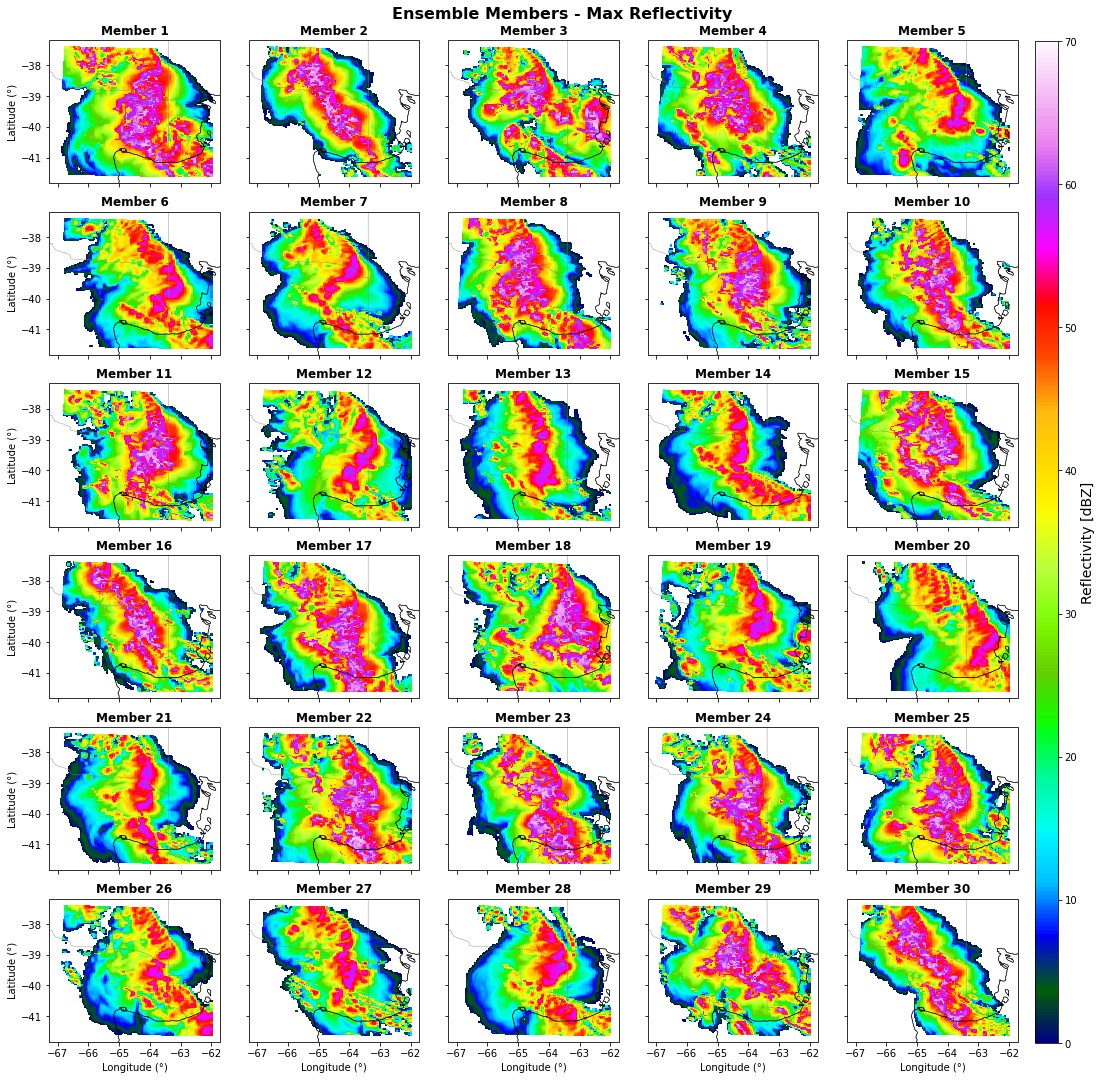

In [115]:
# See all the ensemble members in a 5 by 6 grid
dif_lat = lat_ur_wrf - lat_ll_wrf
dif_lon = lon_ur_wrf - lon_ll_wrf
ncols = 5
nrows = 6
width_fig = 16/ncols
height_fig = width_fig*dif_lat/dif_lon

fig, axs = plt.subplots(nrows, ncols, figsize=(width_fig*ncols, height_fig*nrows), sharex=True, sharey=True,
                        subplot_kw={'projection': ccrs.PlateCarree()}, 
                        gridspec_kw={'hspace': 0.2, 'wspace': 0.1})
axs = axs.flatten()
lats = data['lats']
lons = data['lons']

for i in range(nbv):
    ax = axs[i]
    label = f"Member {i+1}"

    levels = np.arange(0,71,1.)
    data_to_plot =  np.ma.masked_less(np.nanmax(dbz_data_all[:, :, :,i],axis=2).T, 0)
 
    cm = ax.pcolormesh(lons,lats,data_to_plot, cmap="gist_ncar",vmin=0,vmax=70, transform=ccrs.PlateCarree())
    #cm = ax.contourf(data_to_plot, cmap="gist_ncar", levels=levels)
    ax.coastlines(resolution='10m', linewidth=0.6)
    ax.add_feature(countries, linewidth=0.4)
    ax.add_feature(states_provinces, linewidth=0.4)
    
    ax.set_xticks(np.unique(np.round(lons,0)))
    ax.set_yticks(np.unique(np.round(lats,0)))

    #ax.gridlines(draw_labels=True)
    ax.set_title(label, fontweight="bold")
    
    if i % 5 == 0:
        ax.set_ylabel("Latitude (°)")
    if i >= (nrows-1)*ncols:
        ax.set_xlabel("Longitude (°)")

cbar_axis = fig.add_axes([0.91, 0.049, 0.02, 0.90])  # [left, bottom, width, height]
cbar = fig.colorbar(cm, cax=cbar_axis, orientation="vertical", label="Reflectivity [dBZ]")
cbar.set_label("Reflectivity [dBZ]", fontsize=14)
plt.suptitle("Ensemble Members - Max Reflectivity", fontsize=16, fontweight="bold")
plt.subplots_adjust(right=0.9,left=0.05,top=0.95,bottom=0.05)
#plt.tight_layout(rect=[0, 0, 0.91, 0.98])
plt.show()
